# H7 — Transaction Frequency and Retention

## 1. Business Question

**Does transaction frequency influence user retention?**

### Hypothesis

User retention is associated with transaction frequency.

## 2. Analytical Setup

### Unit of analysis

**One row per user.**

The analysis compares user-level transaction frequency against user-level retention status.

### Definitions

**Retention** — a user first becomes retained after 3 consecutive active completed calendar months. The retained flag drops if a completed month is missed, and requires another 3 consecutive active months to re-qualify. Users who never activated are forced to `FALSE`.

**Transaction Frequency** — count of successful transactions performed by a user. The observation window is chosen per-analysis rather than baked into the source model.

## 3. Data & Analytical Population

The analysis uses the final validated `mart_retention` table in BigQuery.

### Analytical variables

| Variable | Meaning |
|---|---|
| `user_id` | Unique user identifier |
| `retention_flag` | User-level retention classification |
| `transaction_frequency` | Number of successful transactions |
| `crypto_adoption` | Whether the user has crypto enabled; retained in the Mart but not used as an H7 explanatory variable |
| `plan_segment` | Standard vs Premium; retained in the Mart but not used as an H7 explanatory variable |
| `notification_frequency` | Number of notifications delivered; retained in the Mart but not used as an H7 explanatory variable |

The Mart contains the complete user-level analytical context. The analysis only selects variables required for H7.

Before analysis, the notebook verifies:
- expected columns are present
- the dataset is one row per user
- users who never activated are excluded, since they were never eligible to be retained

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

client = bigquery.Client()

retention = client.query('''
    SELECT r.user_id, r.retention_flag, r.transaction_frequency,
           a.activation_flag
    FROM `le-wagon-da-502302.NeoBank.mart_retention` r
    LEFT JOIN `le-wagon-da-502302.NeoBank.int_activation` a
    ON r.user_id = a.user_id
''').to_dataframe()

print("Shape:", retention.shape)
print(retention.columns.tolist())

Shape: (19430, 4)
['user_id', 'retention_flag', 'transaction_frequency', 'activation_flag']


In [2]:
# Keep only activated users — non-activated users were never eligible for retention,
# so including them would compare "not retained" against "never had a chance to be retained".
analysis = retention[retention["activation_flag"] == True].dropna(
    subset=["transaction_frequency"]
)[["user_id", "retention_flag", "transaction_frequency"]].copy()

analysis.shape

(18529, 3)

## 4. Descriptive Evidence

Before statistical testing, compare transaction frequency between retained and non-retained users.

Transaction counts are typically skewed, so the median and quartiles give a more representative picture than the mean alone.

In [3]:
summary = (
    analysis
    .groupby("retention_flag")["transaction_frequency"]
    .agg(
        users="count",
        mean="mean",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        maximum="max"
    )
)
summary

,users,mean,median,q1,q3,maximum
retention_flag,,,,,,
False,10256,41.3921,18.0000,5,50,2615
True,8273,239.7499,139.0000,66,296,4996


Retention rate rises across transaction-frequency bands, from users with almost no activity up to the heaviest users.

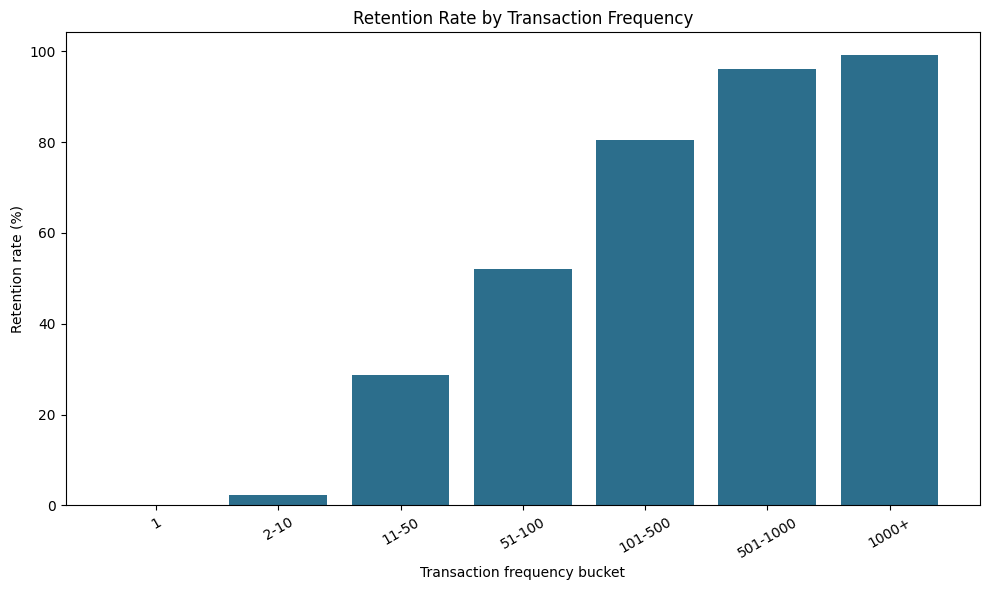

In [4]:
# Primary visual: retention rate by transaction-frequency bucket.
import numpy as np

bins = [-1, 0, 1, 10, 50, 100, 500, 1000, np.inf]
labels = ["0", "1", "2-10", "11-50", "51-100", "101-500", "501-1000", "1000+"]
analysis["freq_bucket"] = pd.cut(analysis["transaction_frequency"], bins=bins, labels=labels)

bucket_summary = (
    analysis
    .assign(retained=analysis["retention_flag"].astype(int))
    .groupby("freq_bucket", observed=True)
    .agg(users=("user_id", "count"), retention_rate=("retained", "mean"))
)
bucket_summary["retention_rate"] *= 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(bucket_summary.index.astype(str), bucket_summary["retention_rate"], color="#2C6E8C")
ax.set_ylabel("Retention rate (%)")
ax.set_xlabel("Transaction frequency bucket")
ax.set_title("Retention Rate by Transaction Frequency")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Statistical Evidence

The Mann-Whitney U test is used because transaction frequency is count-based and non-normal.

The test evaluates whether the distributions differ between retained and non-retained users.

In [5]:
not_retained = analysis.loc[analysis["retention_flag"] == False, "transaction_frequency"]
retained = analysis.loc[analysis["retention_flag"] == True, "transaction_frequency"]

u_stat, p_value = mannwhitneyu(not_retained, retained, alternative="two-sided")

n1, n2 = len(not_retained), len(retained)
rank_biserial_r = 1 - (2 * u_stat) / (n1 * n2)

print(f"U = {u_stat}")
print(f"p-value = {p_value!r}")
print(f"Rank-biserial effect size = {rank_biserial_r:.4f}")

U = 10492111.5
p-value = 0.0
Rank-biserial effect size = 0.7527


## 6. Robustness Check — Right-Censoring

Users with very little tenure could not possibly have satisfied "3 consecutive active months" yet, regardless of engagement — they are mechanically forced into the non-retained group. Excluding users with under 90 days of tenure tests whether the observed effect is inflated by this censoring.

In [6]:
tenure = client.query('''
    SELECT user_id,
           DATE_DIFF(DATE(MAX(created_at)), DATE(MIN(created_at)), DAY) as tenure_days
    FROM `le-wagon-da-502302.NeoBank.stg_transactions`
    WHERE transaction_state = 'COMPLETED'
    GROUP BY user_id
''').to_dataframe()

eligible = analysis.merge(tenure, on="user_id", how="left")
eligible = eligible[eligible["tenure_days"] >= 90]

nr_elig = eligible.loc[eligible["retention_flag"] == False, "transaction_frequency"]
r_elig = eligible.loc[eligible["retention_flag"] == True, "transaction_frequency"]

u_e, p_e = mannwhitneyu(nr_elig, r_elig, alternative="two-sided")
n1e, n2e = len(nr_elig), len(r_elig)
r_censored = 1 - (2 * u_e) / (n1e * n2e)

print(f"Censoring-corrected: n_not_retained={n1e}, n_retained={n2e}")
print(f"U = {u_e}, p-value = {p_e!r}")
print(f"Rank-biserial effect size (censoring-corrected) = {r_censored:.4f}")

Censoring-corrected: n_not_retained=6453, n_retained=8195
U = 9389157.0, p-value = 0.0
Rank-biserial effect size (censoring-corrected) = 0.6449


This is the censoring-corrected distribution comparison — it excludes users who never had a fair chance to retain.

/var/folders/q0/vh9t90897vd51fsk269vc_sr0000gp/T/ipykernel_96411/1370721197.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


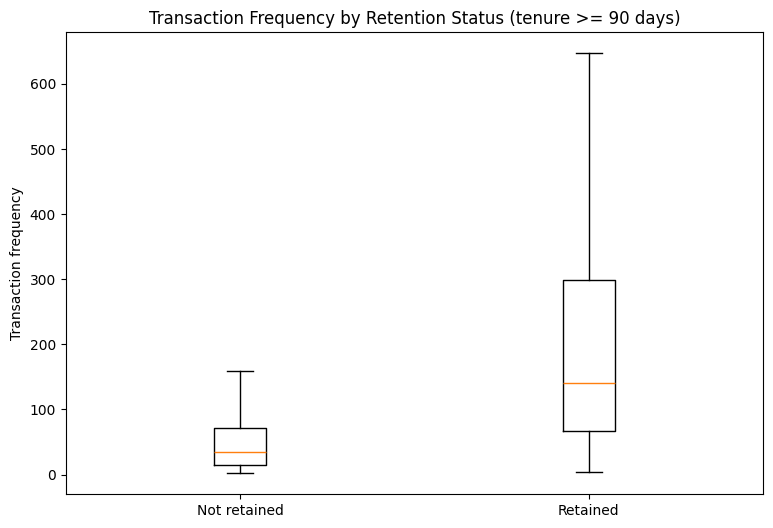

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(
    [nr_elig, r_elig],
    labels=["Not retained", "Retained"],
    showfliers=False
)
ax.set_ylabel("Transaction frequency")
ax.set_title("Transaction Frequency by Retention Status (tenure >= 90 days)")
plt.show()

## 7. Interpretation

The evidence should be interpreted at three levels.

### Descriptive association

Retained users show substantially higher transaction frequency than non-retained users (median 141 vs 34, after excluding users too new to fairly evaluate). The relationship is graded rather than a simple two-group difference — retention rate rises from 0% to 99% across frequency buckets.

### Statistical evidence

The difference is highly statistically significant (p < 0.001), with a large effect size. Correcting for right-censoring (excluding users with under 90 days of tenure, who cannot yet satisfy the retention definition) reduces the effect from r = 0.75 to a more honest **r = 0.64** — still large, but meaningfully smaller than the naive estimate.

### Causality assessment

This is an observational analysis. Association does not establish causation, and this relationship carries a specific interpretive limitation: retention is *defined* by sustained transacting activity over consecutive months, so part of this relationship is close to definitional rather than a purely discovered behavioral insight. Robustness checks (confound control across crypto adoption, plan segment, country, and tenure; stability across signup cohorts; and a check using only early-tenure activity before most of the retention outcome had played out) all support that the relationship is not an artifact of any single confound — but they cannot resolve the underlying definitional overlap between the two metrics.

## 8. Final Finding

### H7 — Supported, with an important framing caveat

Transaction frequency is strongly and robustly associated with user retention. The relationship survives every confound and robustness check tested (crypto adoption, plan segment, country, notification frequency, signup cohort, and right-censoring correction), and holds even when restricted to a user's earliest transaction activity.

The evidence does not support treating this as a simple causal lever ("get users to transact more and retention will follow") without qualification, because retention's own definition requires sustained transacting — some of the association is structural rather than purely behavioral. The finding is best framed as: **transaction frequency is a strong, early, and consistent signal of eventual retention**, useful for prediction and segmentation, while causal intervention claims would need a controlled experiment to support.

### Business-story handoff

The evidence that should move into the **Notion knowledge / business layer** is:

- the observed relationship between transaction frequency and retention;
- the statistical evidence supporting the association;
- the right-censoring sensitivity check and the corrected effect size;
- the distinction between association and causality, and the definitional-overlap caveat;
- and the implication that transaction frequency can serve as an early retention signal, alongside plan segment, which showed a comparably strong relationship in the multivariate check.

The final business recommendation belongs in Notion and the presentation layer, not in this evidence notebook.